In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('matches_cleaned.csv')


### Team analysis

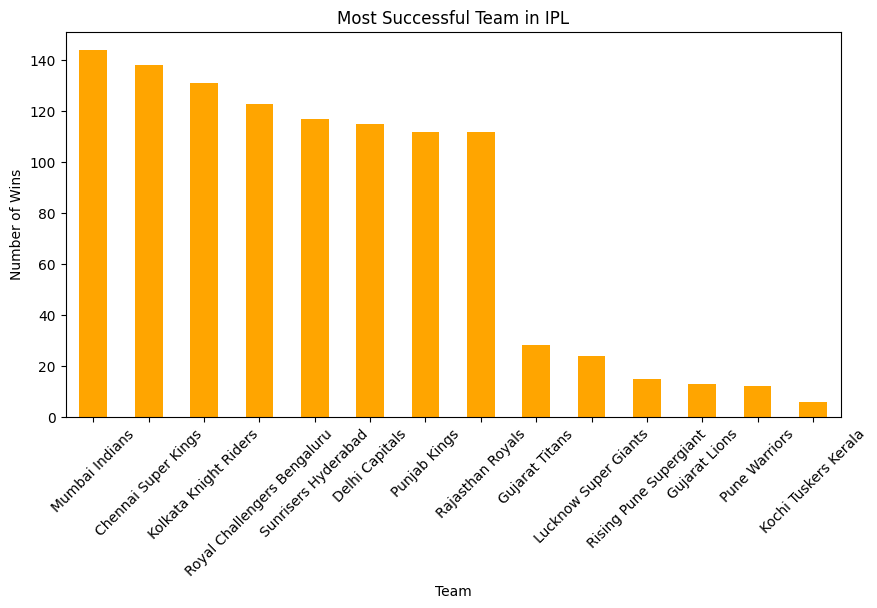

In [3]:
# most successful team in IPL
df['winner'].value_counts().plot(kind='bar', figsize=(10,5), color='orange')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.title('Most Successful Team in IPL')
plt.xticks(rotation=45)
plt.show()

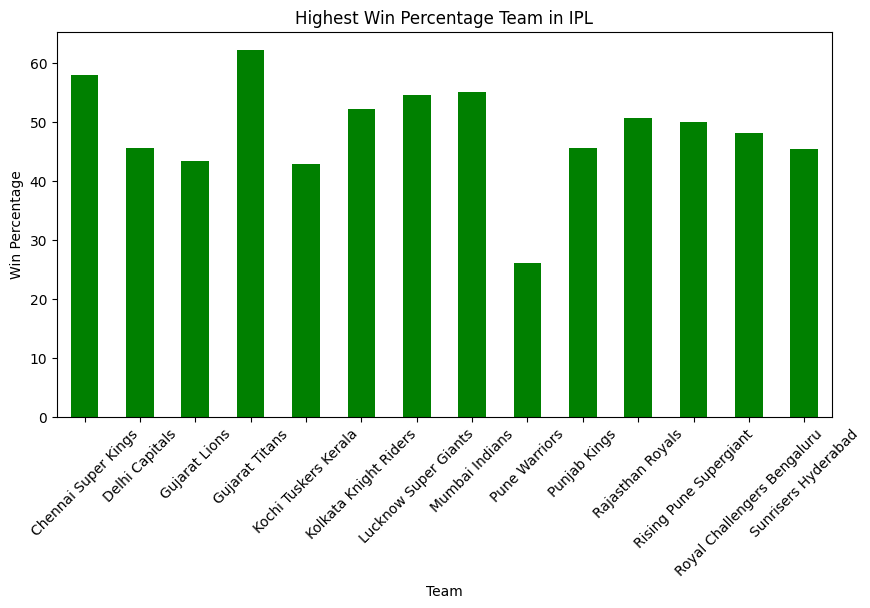

In [4]:
# Highest win percentage team in IPL
win_percentage = (df['winner'].value_counts() / (df['team1'].value_counts()+df['team2'].value_counts()))*100
win_percentage.plot(kind='bar', figsize=(10,5), color='green')
plt.xlabel('Team')
plt.ylabel('Win Percentage')
plt.title('Highest Win Percentage Team in IPL')
plt.xticks(rotation=45)
plt.show()

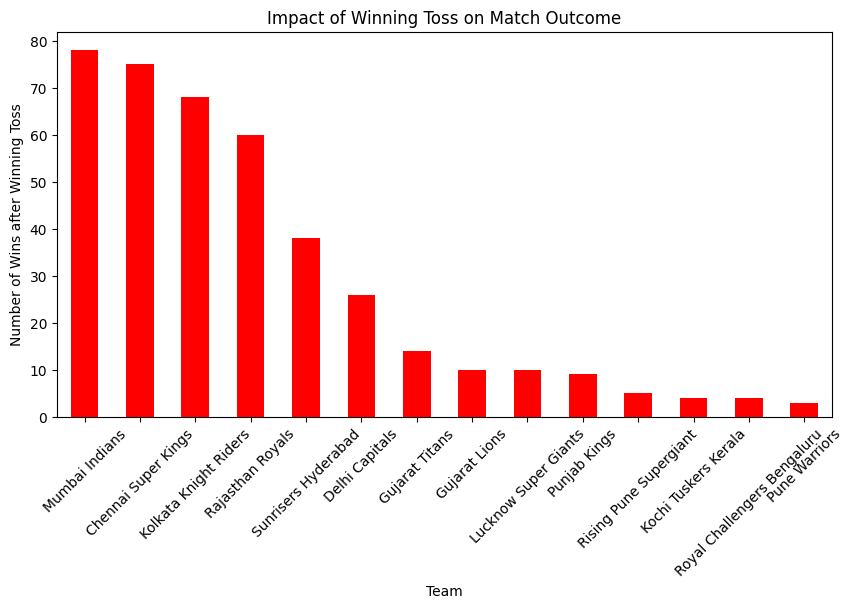

In [5]:
# toss impact on match outcome
toss_win = df[df['toss_winner'] == df['winner']]
toss_win['toss_winner'].value_counts().plot(kind='bar', figsize=(10,5), color='red')
plt.xlabel('Team')
plt.ylabel('Number of Wins after Winning Toss')
plt.title('Impact of Winning Toss on Match Outcome')
plt.xticks(rotation=45)
plt.show()

In [19]:
# Average Team Scores in IPL
df[['team1', 'team2',]]df2['total_runs'].groupby(['team1', 'team2']).mean().reset_index().groupby('team1')['total_runs'].mean().plot(kind='bar', figsize=(10,5), color='purple')
plt.xlabel('Team')
plt.ylabel('Average Total Runs')
plt.title('Average Team Scores in IPL')
plt.xticks(rotation=60)
plt.tight_layout()

SyntaxError: invalid syntax (2329802655.py, line 2)

### Player Analysis

In [6]:
df2=pd.read_csv('cleaned_deliveries.csv')

In [7]:
df2['is_wicket'].unique()


array([0, 1])

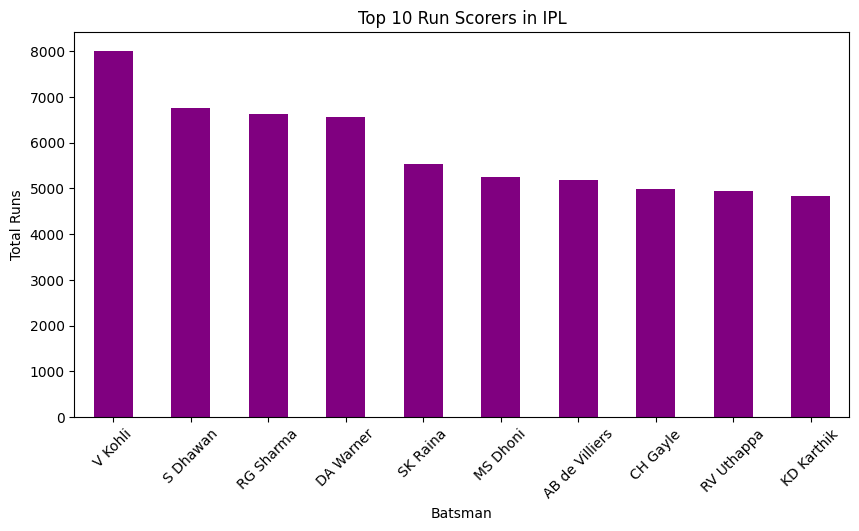

In [8]:
# top 10 run scorers in IPL
top_scorers = df2.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
top_scorers.plot(kind='bar', figsize=(10,5), color='purple')
plt.xlabel('Batsman')
plt.ylabel('Total Runs')
plt.title('Top 10 Run Scorers in IPL')
plt.xticks(rotation=45)
plt.show()

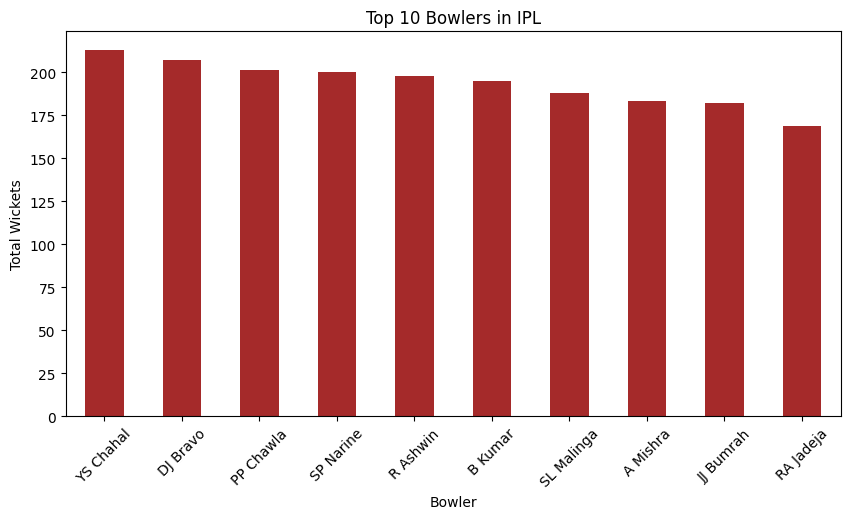

In [9]:
# top 10 bowlers in IPL
top_10_bowlers = df2.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)
top_10_bowlers.plot(kind='bar', figsize=(10,5), color='brown')
plt.xlabel('Bowler') 
plt.ylabel('Total Wickets')
plt.title('Top 10 Bowlers in IPL')
plt.xticks(rotation=45)
plt.show()

### Venue Analysis

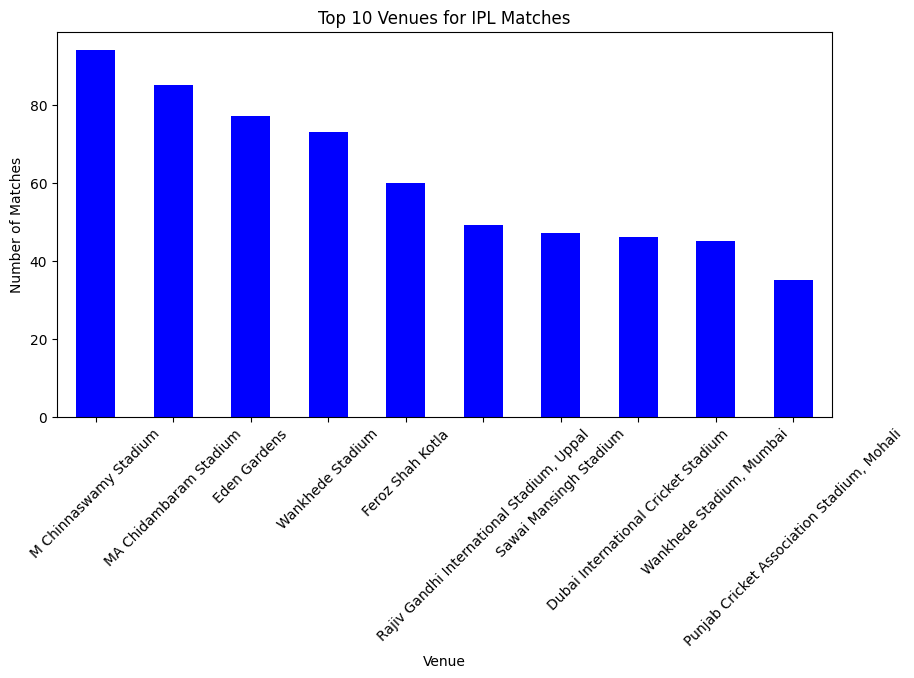

In [10]:
# Most Matches played in IPL venues
df['venue'].value_counts().head(10).plot(kind='bar', figsize=(10,5), color='blue')
plt.xlabel('Venue')
plt.ylabel('Number of Matches')
plt.title('Top 10 Venues for IPL Matches')
plt.xticks(rotation=45)
plt.show()

In [11]:
df2

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,Not Dismissed,Not Out,No Fielder
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,Normal,0,Not Dismissed,Not Out,No Fielder
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,Not Dismissed,Not Out,No Fielder
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,Normal,0,Not Dismissed,Not Out,No Fielder
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,Normal,0,Not Dismissed,Not Out,No Fielder
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260915,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,VR Iyer,1,0,1,Normal,0,Not Dismissed,Not Out,No Fielder
260916,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,SS Iyer,1,0,1,Normal,0,Not Dismissed,Not Out,No Fielder
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,0,1,Normal,0,Not Dismissed,Not Out,No Fielder
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,0,1,Normal,0,Not Dismissed,Not Out,No Fielder


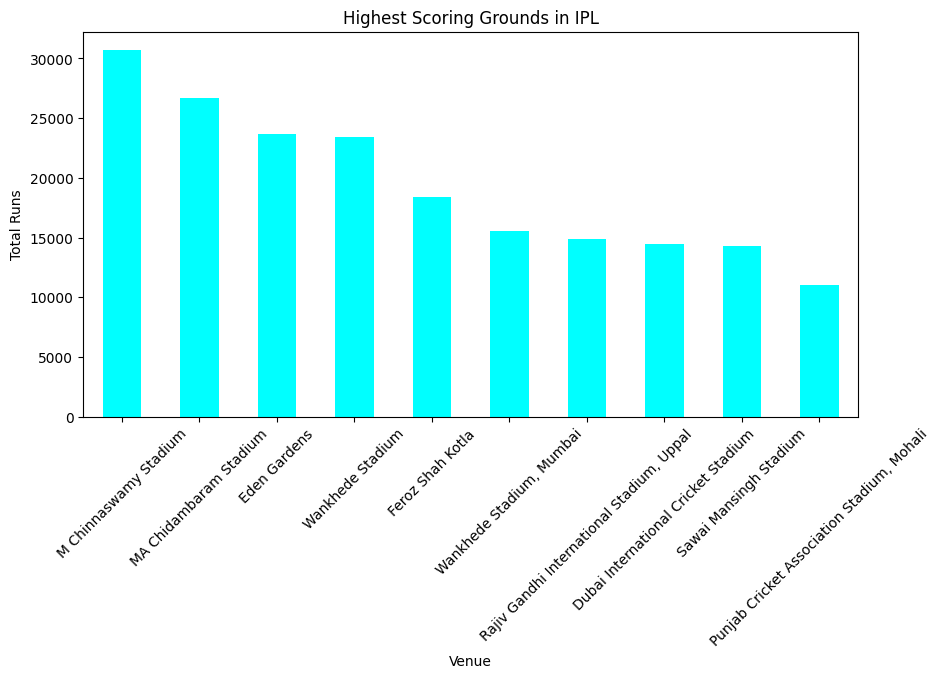

In [12]:
# highest sccoring ground in IPL
highest_scoring_ground = df2.merge(df[['id','venue']], left_on='match_id', right_on='id').groupby('venue')['total_runs'].sum().sort_values(ascending=False).head(10)
highest_scoring_ground.plot(kind='bar', figsize=(10,5), color='cyan')
plt.xlabel('Venue')
plt.ylabel('Total Runs')
plt.title('Highest Scoring Grounds in IPL')
plt.xticks(rotation=45)
plt.show()

In [13]:
# Average 1st innings score in IPL
first_innings_scores = df2[df2['inning'] == 1].groupby('match_id')['total_runs'].sum()
average_first_innings_score = first_innings_scores.mean()
print(f"Average 1st innings score in IPL: {average_first_innings_score}")

Average 1st innings score in IPL: 165.54703196347032


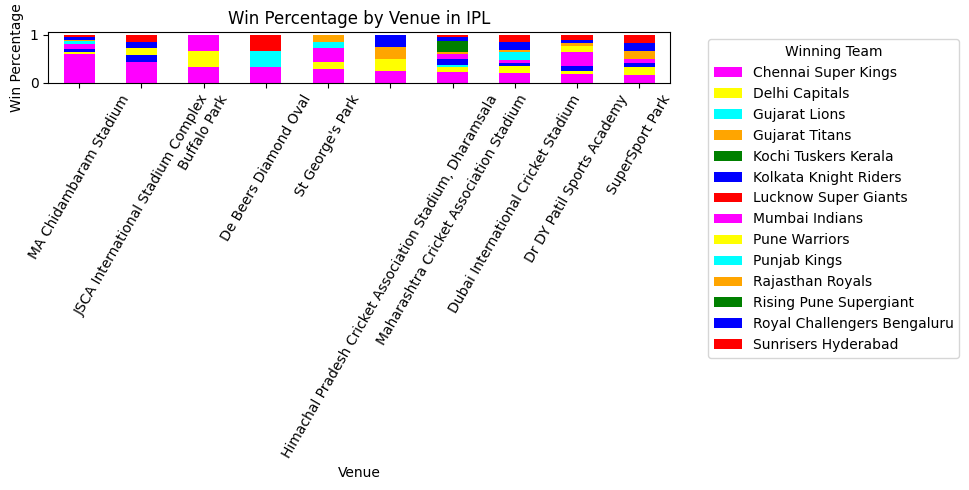

In [17]:
# Top 10 venue with the highest win percentage
venue_win_percentage = df.groupby('venue')['winner'].value_counts(normalize=True).unstack().fillna(0)
venue_win_percentage = venue_win_percentage.sort_values(by=venue_win_percentage.columns.tolist(), ascending=False).head(10)
venue_win_percentage.plot(kind='bar', stacked=True, figsize=(10,5), color=['magenta', 'yellow', 'cyan', 'orange', 'green', 'blue', 'red'])
plt.xlabel('Venue')
plt.ylabel('Win Percentage')
plt.title('Win Percentage by Venue in IPL')
plt.xticks(rotation=60)
plt.legend(title='Winning Team', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

C:\Users\Rajat\AppData\Local\Temp\ipykernel_12864\3997939775.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


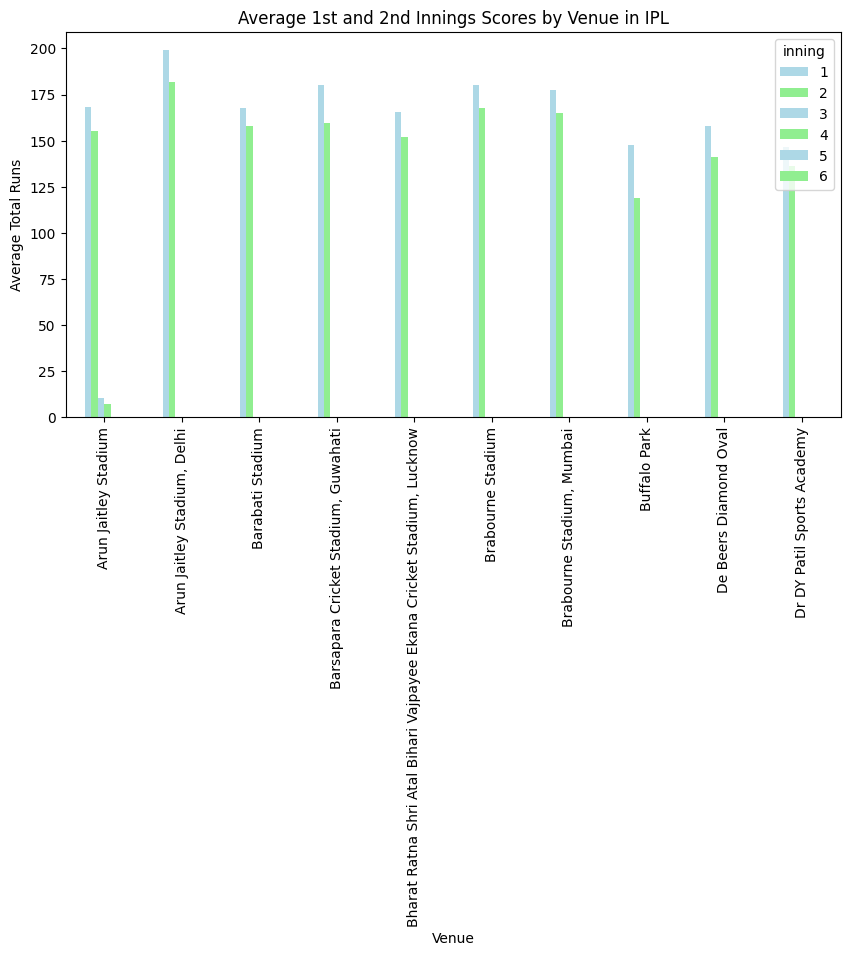

In [30]:
# venue with 1st and 2nd innings average score

venue_innings_scores = (
    df2.merge(
        df[['id', 'venue']],
        left_on='match_id',
        right_on='id'
    )
    .groupby(['venue', 'match_id', 'inning'])['total_runs']
    .sum()                      # innings total
    .reset_index()
    .groupby(['venue', 'inning'])['total_runs']
    .mean()                     # average innings score
    .unstack()
    .head(10)
)
venue_innings_scores.plot(kind='bar', figsize=(10,5), color=['lightblue', 'lightgreen'])
plt.xlabel('Venue')
plt.ylabel('Average Total Runs')
plt.title('Average 1st and 2nd Innings Scores by Venue in IPL')
plt.tight_layout()
plt.show()